In [10]:
import pandas as pd
import os

In [4]:
df = pd.read_csv('../data/eia_load_profiles/2021_hourly_demand_by_rto.csv', parse_dates=['timestamp'])

In [32]:
regional_profiles = {}
hourly_demand_path = "../eia_data_cleaner/data/regional_forecast/outputs"
for fname in os.listdir(hourly_demand_path):
    fpath = os.path.join(hourly_demand_path, fname)
    if os.path.isdir(fpath):
        continue
    df = (
        pd.read_csv(fpath, parse_dates=["date_time"])
        .rename(columns={'date_time': 'timestamp', 'cleaned demand (MW)': 'value'})
        .set_index("timestamp")
        [["value"]]
    )
    region = fname.replace('.csv', '')
    regional_profiles[region] = df

<Axes: xlabel='timestamp'>

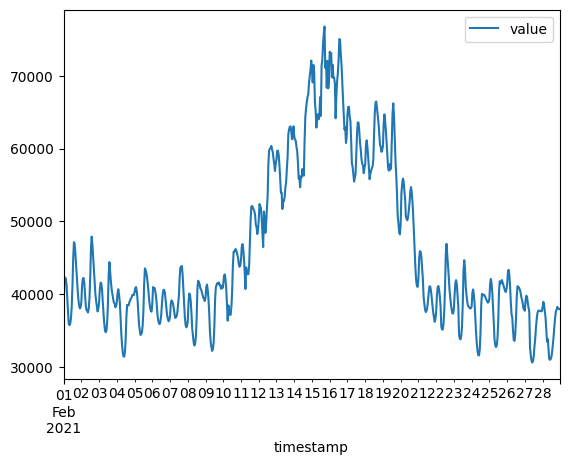

In [35]:
regional_profiles['ERCO'].loc[(
    (regional_profiles['ERCO'].index.year == 2021)
    & (regional_profiles['ERCO'].index.month == 2)
)].plot()

In [18]:
subregional_profiles = {}
hourly_subregion_demand_path = "../eia_data_cleaner/data/subregional/outputs"
for fname in os.listdir(hourly_subregion_demand_path):
    fpath = os.path.join(hourly_subregion_demand_path, fname)
    if os.path.isdir(fpath):
        continue
    df = (
        pd.read_csv(fpath, parse_dates=["date_time"])
        .rename(columns={'date_time': 'timestamp', 'cleaned demand (MW)': 'value'})
        .set_index("timestamp")
        [["value"]]
    )
    subregion = fname.replace('.csv', '')
    subregional_profiles[subregion] = df

<Axes: xlabel='timestamp'>

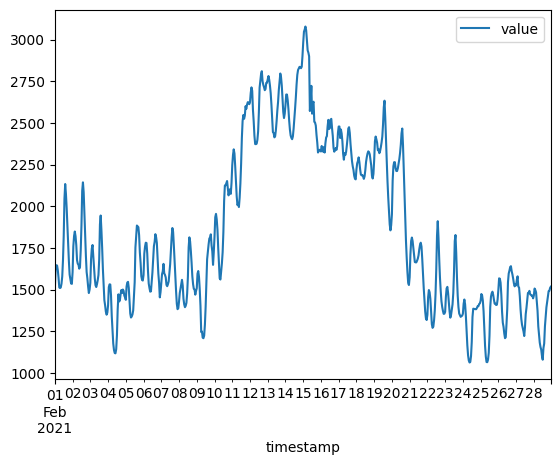

In [31]:
subregional_profiles['EAST'].loc[(
    (subregional_profiles['EAST'].index.year == 2021)&
    (subregional_profiles['EAST'].index.month ==2)
)].plot()

<Axes: xlabel='timestamp'>

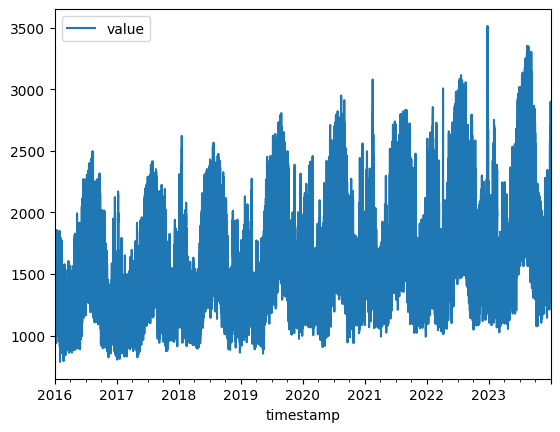

In [29]:
subregional_profiles['EAST'].plot()

<Axes: xlabel='timestamp'>

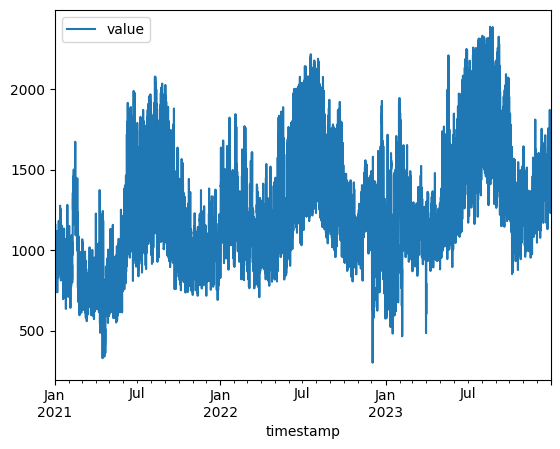

In [28]:
subregional_profiles['NRTH'].loc[(
    (subregional_profiles['NRTH'].index.year.isin([2021, 2022, 2023]))
    # & (subregional_profiles['EAST'].index.month == 2)
)].plot()

<Axes: xlabel='timestamp'>

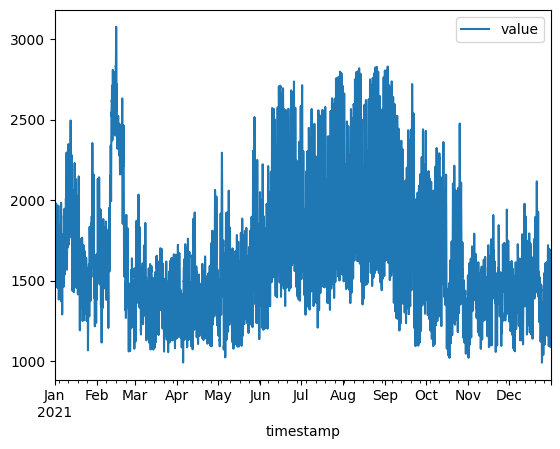

In [23]:
subregional_profiles['EAST'].loc[(
    (subregional_profiles['EAST'].index.year == 2021)
    # & (subregional_profiles['EAST'].index.month == 2)
)].plot()

<Axes: xlabel='timestamp'>

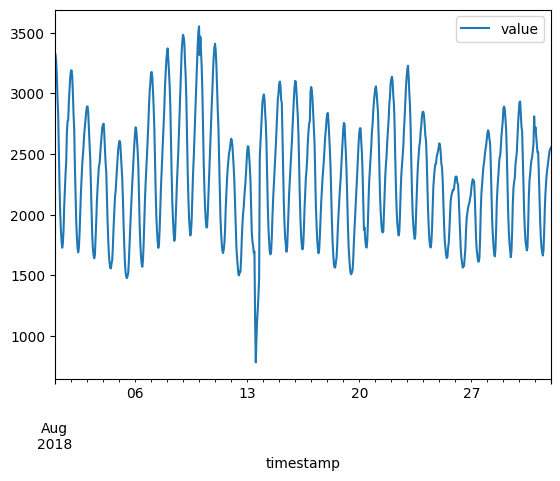

In [16]:
regional_profiles['PACW'].loc[(
    (regional_profiles['PACW'].index.year == 2018)
    & (regional_profiles['PACW'].index.month == 8)
)].plot()

<Axes: xlabel='timestamp'>

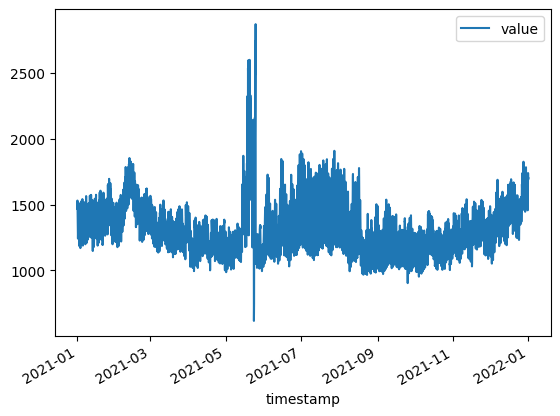

In [8]:
df.loc[df.respondent == 'NWMT'].plot(x='timestamp', y='value')